# Movie Recommendation System
A hybrid recommendation system built using the MovieLens dataset, combining content-based and collaborative filtering.

## Step 1 : Importing Libaries and Loading Data

In [67]:
import pandas as pd 
import numpy as np 

movies= pd.read_csv("movies.csv") #pandas is a library that reads the contents of a csv file and stores it in a table or dataFrame
ratings=pd.read_csv("ratings.csv")

print(movies.shape) #shape gives us rows and colums as (rows,colums)
print(ratings.shape)

print(movies.head()) #prints the first few rows 



(9742, 3)
(100836, 4)
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


## Step 2 : Checking For Missing Values 

In [68]:
print(movies.isnull().sum()) #counts the number of null values 
print(ratings.isnull().sum())

movieId    0
title      0
genres     0
dtype: int64
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


## Step 3 : Content-Based Filtering -> Building The Genre Soup

In [69]:
movies["soup"]=movies["genres"].str.replace("|"," ",regex=False)

print(movies[["title","soup"]].head(3)) #replacing this | with space and printing the first three rows 

                     title                                         soup
0         Toy Story (1995)  Adventure Animation Children Comedy Fantasy
1           Jumanji (1995)                   Adventure Children Fantasy
2  Grumpier Old Men (1995)                               Comedy Romance


## Step 4 : Vectorising with CountVectorizer 

In [70]:
from sklearn.feature_extraction.text import CountVectorizer #countVectorizer coverts text into numbers 
cv = CountVectorizer(stop_words='english') # stop_words=english, ignores common words
count_matrix = cv.fit_transform(movies['soup']) #fit->learns the vocablury of the genres and transform->converts the text into numbers 

print("Matrix shape:", count_matrix.shape)
print("Genres found:", cv.get_feature_names_out()) #shows all the unique words that the CountVectorizer has learnt

Matrix shape: (9742, 23)
Genres found: ['action' 'adventure' 'animation' 'children' 'comedy' 'crime'
 'documentary' 'drama' 'fantasy' 'fi' 'film' 'genres' 'horror' 'imax'
 'listed' 'musical' 'mystery' 'noir' 'romance' 'sci' 'thriller' 'war'
 'western']


## Step 5 : Computing Cosine Similarity 

In [71]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(count_matrix, count_matrix)
print("Similarity matrix shape:", cosine_sim.shape)

Similarity matrix shape: (9742, 9742)


## Step 6 : Content-Based Recommendation Function

In [72]:
movies = movies.reset_index()
indices = pd.Series(movies.index, index=movies['title'])

def content_recommend(title):
    if title not in indices:
        return f"Movie '{title}' not found in dataset."
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]
    return movies['title'].iloc[movie_indices].tolist()

print(content_recommend('Toy Story (1995)'))

['Antz (1998)', 'Toy Story 2 (1999)', 'Adventures of Rocky and Bullwinkle, The (2000)', "Emperor's New Groove, The (2000)", 'Monsters, Inc. (2001)', 'Wild, The (2006)', 'Shrek the Third (2007)', 'Tale of Despereaux, The (2008)', 'Asterix and the Vikings (Astérix et les Vikings) (2006)', 'Turbo (2013)']


## Step 7 : Collaborative Filtering -> Preparing The Ratings Data 

In [73]:
ratings = ratings.drop('timestamp', axis=1)

print(ratings.head())
print("\nRating range:", ratings['rating'].min(), "to", ratings['rating'].max())
print("Unique users:", ratings['userId'].nunique())
print("Unique movies:", ratings['movieId'].nunique())

   userId  movieId  rating
0       1        1     4.0
1       1        3     4.0
2       1        6     4.0
3       1       47     5.0
4       1       50     5.0

Rating range: 0.5 to 5.0
Unique users: 610
Unique movies: 9724


## Step 8 : Loading Data Into Surprise 

In [74]:
from surprise import Dataset, Reader
from surprise.model_selection import train_test_split

reader = Reader(rating_scale=(0.5, 5.0))

data = Dataset.load_from_df(
    ratings[['userId', 'movieId', 'rating']],
    reader
)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

## Step 9 : Training The SVD Model 

In [75]:
from surprise import SVD

algo = SVD(random_state=42)
algo.fit(trainset)

test_prediction = algo.predict(uid=1, iid=1)
print("Predicted rating for user 1, movie 1:", round(test_prediction.est, 2))

Predicted rating for user 1, movie 1: 4.57


## Step 10 : Evaluating Model Accuracy With RMSE

In [76]:
from surprise import accuracy

predictions = algo.test(testset)
rmse = accuracy.rmse(predictions)
print(f"RMSE: {rmse:.4f}")

RMSE: 0.8807
RMSE: 0.8807


## Step 11 : Collaborative Recommendation Function 

In [77]:
def collab_recommend(user_id, n=10):
    rated_movies = ratings[ratings['userId'] == user_id]['movieId'].tolist()
    all_movie_ids = movies['movieId'].tolist()
    unrated = [m for m in all_movie_ids if m not in rated_movies]

    predictions = [algo.predict(user_id, mid) for mid in unrated]
    predictions.sort(key=lambda x: x.est, reverse=True)
    top_ids = [p.iid for p in predictions[:n]]

    return movies[movies['movieId'].isin(top_ids)][['title', 'genres']]

print(collab_recommend(user_id=1))


                                                 title  \
474                                Blade Runner (1982)   
596         Ghost in the Shell (Kôkaku kidôtai) (1995)   
602  Dr. Strangelove or: How I Learned to Stop Worr...   
690                          North by Northwest (1959)   
694                                  Casablanca (1942)   
841                   Streetcar Named Desire, A (1951)   
878     Cinema Paradiso (Nuovo cinema Paradiso) (1989)   
896             One Flew Over the Cuckoo's Nest (1975)   
906                          Lawrence of Arabia (1962)   
924    Grand Day Out with Wallace and Gromit, A (1989)   

                                         genres  
474                      Action|Sci-Fi|Thriller  
596                            Animation|Sci-Fi  
602                                  Comedy|War  
690   Action|Adventure|Mystery|Romance|Thriller  
694                               Drama|Romance  
841                                       Drama  
878        

##  Step 12 : Hybrid Recommendation Function 

In [78]:
from sklearn.preprocessing import MinMaxScaler

def hybrid_recommend(user_id, movie_title, alpha=0.5, n=10):
    if movie_title not in indices:
        return f"Movie '{movie_title}' not found."

    idx = indices[movie_title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:21]

    candidates = movies.iloc[[i[0] for i in sim_scores]].copy()
    candidates['content_score'] = [s[1] for s in sim_scores]

    candidates['collab_score'] = candidates['movieId'].apply(
        lambda mid: algo.predict(user_id, mid).est
    )

    scaler = MinMaxScaler()
    candidates[['content_score', 'collab_score']] = scaler.fit_transform(
        candidates[['content_score', 'collab_score']]
    )

    candidates['hybrid_score'] = (
        alpha * candidates['content_score'] +
        (1 - alpha) * candidates['collab_score']
    )

    result = candidates.sort_values('hybrid_score', ascending=False)
    return result[['title', 'genres', 'hybrid_score']].head(n)

print(hybrid_recommend(user_id=1, movie_title='Toy Story (1995)'))

                                                  title  \
2355                                 Toy Story 2 (1999)   
3568                              Monsters, Inc. (2001)   
8219                                       Turbo (2013)   
3000                   Emperor's New Groove, The (2000)   
9430                                       Moana (2016)   
8927                           The Good Dinosaur (2015)   
1706                                        Antz (1998)   
7760  Asterix and the Vikings (Astérix et les Viking...   
6194                                   Wild, The (2006)   
6948                     Tale of Despereaux, The (2008)   

                                           genres  hybrid_score  
2355  Adventure|Animation|Children|Comedy|Fantasy      0.976213  
3568  Adventure|Animation|Children|Comedy|Fantasy      0.936811  
8219  Adventure|Animation|Children|Comedy|Fantasy      0.839820  
3000  Adventure|Animation|Children|Comedy|Fantasy      0.831592  
9430  Adventure|Anim

## Step 13 : Exploratory Data Analysis 

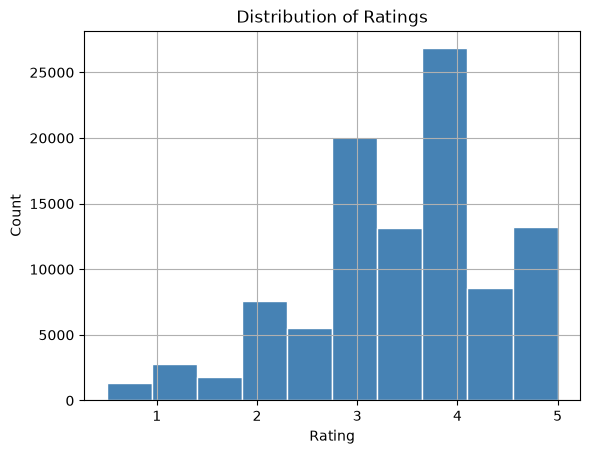

In [79]:
import matplotlib.pyplot as plt

ratings['rating'].hist(bins=10, color='steelblue', edgecolor='white')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

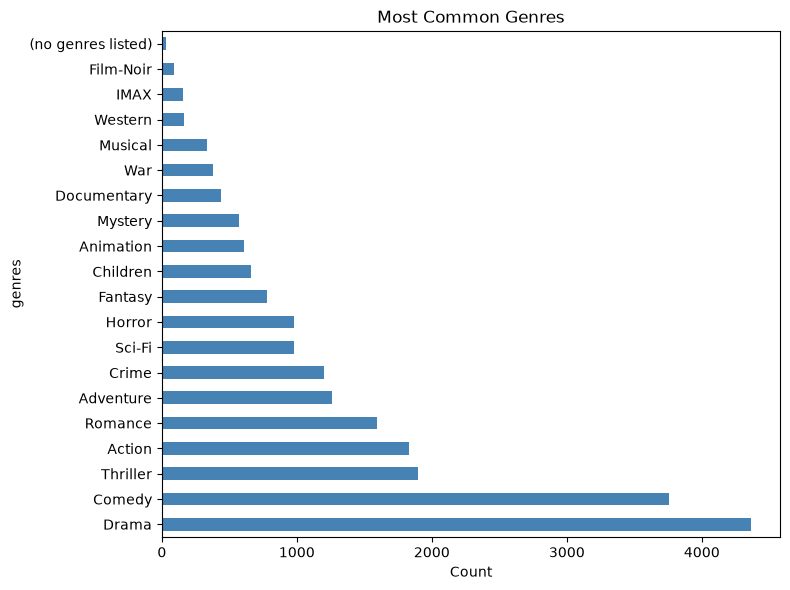

In [80]:
genre_counts = movies['genres'].str.split('|').explode().value_counts()
genre_counts.plot(kind='barh', figsize=(8,6), color='steelblue')
plt.title('Most Common Genres')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

## Conclusion
This project built a hybrid movie recommendation system using the MovieLens dataset. Content-based filtering recommends movies based on genre similarity, while collaborative filtering learns from user rating patterns using SVD. The hybrid model combines both approaches with a tunable alpha parameter, achieving an RMSE of 0.8807. A future improvement would be enriching the content features with cast and director data from TMDB for more nuanced recommendations.